In [142]:
import pandas as pd
import glob
import os
import re
import sys
from omegaconf import OmegaConf

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.analysis.sensitivity import SensitivityAnalyzer
from src.validity.validity_criteria import validate_polarization_curves
parameter_ranges = OmegaConf.load('../param_config.yaml')
parameters = list(parameter_ranges)
parameters.append('ifc')

data = pd.read_pickle('../data/raw/sampled_nathaly_sobol_design_matrix_forN1024.pkl')
#data = pd.read_pickle('../sampling_test/validated_final_df_57344_imputed.pkl')
data = data[~data['Ucell'].isna()]

In [143]:
# --- Expand 'ifc' list into individual columns ---
if "ifc" in data.columns:
    ifc_expanded = pd.DataFrame(data["ifc"].tolist(), index=data.index)
    ifc_expanded.columns = [f"ifc_{i+1}" for i in range(ifc_expanded.shape[1])]
    data = pd.concat([data.drop(columns=["ifc"]), ifc_expanded], axis=1)

# --- Expand 'Ucell' list into individual columns ---
if "Ucell" in data.columns:
    ucell_expanded = pd.DataFrame(data["Ucell"].tolist(), index=data.index)
    ucell_expanded.columns = [f"Ucell_{i+1}" for i in range(ucell_expanded.shape[1])]
    data = pd.concat([data.drop(columns=["Ucell"]), ucell_expanded], axis=1)

In [144]:
from src.validity.validity_criteria import validate_polarization_curves
criteria = {
    "start_in_range": True,
    "approx_monotonic": True,
    "low_ifc_positive_voltage": True
}

validated_df = validate_polarization_curves(
    data,
    apply_criteria=criteria,
    filter_invalid=True,
    voltage_range=(0, 1.23),
    approx_monotonic_threshold=0.05
)

print(len(validated_df))

33024


In [145]:
# Select only columns that start with "Ucell_"
ucell_columns = [col for col in validated_df.columns if col.startswith("Ucell_")]

# Filter rows where all those columns are > 0
filtered_df = validated_df[validated_df[ucell_columns].gt(0).all(axis=1)]

In [134]:
columns = list(parameter_ranges.keys())
columns.extend(['Ucell', 'ifc', 'SHA256'])

n_configs = 10000
sampled_df = filtered_df.sample(n=n_configs, random_state=42).reset_index(drop=True)

# Identify the relevant columns
ucell_cols = [col for col in sampled_df.columns if col.startswith("Ucell_")]
ifc_cols = [col for col in sampled_df.columns if col.startswith("ifc_")]

# Combine the columns into lists
sampled_df["Ucell"] = sampled_df[ucell_cols].values.tolist()
sampled_df["ifc"] = sampled_df[ifc_cols].values.tolist()

# Explode both columns together
df_exploded = sampled_df[columns].explode(['ifc', 'Ucell'], ignore_index=True)

print("\nExploded DataFrame:")
print(len(df_exploded))
df_exploded.head()


Exploded DataFrame:
310000


,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Ucell,ifc,SHA256
0,336.662606,141711.990414,2.700951,0.325121,0.580939,2.734581,0.28878,0.280823,4,0.000002,54.030747,35.744282,2.395072,1.117318,0.000823,None
1,336.662606,141711.990414,2.700951,0.325121,0.580939,2.734581,0.28878,0.280823,4,0.000002,54.030747,35.744282,2.395072,1.048181,0.100822,None
2,336.662606,141711.990414,2.700951,0.325121,0.580939,2.734581,0.28878,0.280823,4,0.000002,54.030747,35.744282,2.395072,1.00557,0.200822,None
3,336.662606,141711.990414,2.700951,0.325121,0.580939,2.734581,0.28878,0.280823,4,0.000002,54.030747,35.744282,2.395072,0.972924,0.300822,None
4,336.662606,141711.990414,2.700951,0.325121,0.580939,2.734581,0.28878,0.280823,4,0.000002,54.030747,35.744282,2.395072,0.945804,0.400822,None


In [135]:
xgb_model = pd.read_pickle('../results/sm/xgboost/xgb_nconfig_50000_no_neg_with_outerCV_final_model.pkl')

In [136]:
X = df_exploded[parameters]
X['ifc'] = X['ifc'].astype(float)

y_pred = xgb_model.predict(X)
y_true = df_exploded['Ucell']

C:\Users\dejvi\AppData\Local\Temp\ipykernel_5944\3449782793.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['ifc'] = X['ifc'].astype(float)


In [137]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Calculate residuals
residuals = y_true - y_pred

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")

RMSE: 0.0732
R²: 0.7942
MAE: 0.0293


In [120]:
data1 = pd.read_pickle('../data/raw/sampled_nathaly_sobol_design_matrix_forN1024.pkl')
data2 = pd.read_pickle('../sampling_test/validated_final_df_57344_imputed.pkl')

In [125]:
df = data2[data2['classification'] == 'valid']

In [128]:
df['Ucell']

0        [1.033674925459757, 0.9897215941935267, 0.9578...
1        [1.0214342244475463, 0.975872411158361, 0.9420...
2        [1.0367043384089636, 0.9775523869377504, 0.937...
3        [1.0220001258280074, 0.9841573427336537, 0.956...
4        [1.0333686511614675, 0.9898413057263942, 0.958...
                               ...                        
57339    [1.0645547329420817, 0.9967519378236925, 0.957...
57340    [1.1121829719384597, 1.042297165664303, 1.0009...
57341    [1.0837659496173961, 1.0020309949626398, 0.958...
57342    [1.0704609249686445, 1.000386166223651, 0.9588...
57343    [1.0632244328543075, 0.9933465155371716, 0.952...
Name: Ucell, Length: 56312, dtype: object

In [ ]:
df[]

,SHA256,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,...,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,classification
0,11170333c7cff3594b57670d910e23c0cfb512b9993b1f...,345.931298,268431.866782,2.632068,0.132128,0.624495,3.519430,0.324434,0.240591,5,...,0.729581,0.720127,0.710685,0.701266,0.691858,0.682437,0.672987,0.663492,0.653933,valid
1,8e2c7334fc6d523390f9e223d856240c78e571a51f1f0c...,350.820492,268431.866782,2.632068,0.132128,0.624495,3.519430,0.324434,0.240591,5,...,0.714529,0.707308,0.699520,0.691411,0.682963,0.674201,0.665215,0.656067,0.646718,valid
2,2d5bbaacfbbf0565bf81093360b4944766eca564d7f371...,345.931298,201919.596742,2.632068,0.132128,0.624495,3.519430,0.324434,0.240591,5,...,0.674925,0.678619,0.672719,0.664526,0.658328,0.651771,0.644673,0.636798,0.628506,valid
3,6e4e3de84bc725483d930efb9067c9aea5d44bd64cc913...,345.931298,268431.866782,1.789658,0.132128,0.624495,3.519430,0.324434,0.240591,5,...,0.716600,0.706744,0.696881,0.686989,0.677044,0.667028,0.656922,0.646707,0.636362,valid
4,8f70543ab8533dbec57dafb0546082beb9108067814b0c...,345.931298,268431.866782,2.632068,0.145910,0.624495,3.519430,0.324434,0.240591,5,...,0.729362,0.719902,0.710475,0.701074,0.691673,0.682255,0.672806,0.663305,0.653740,valid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57339,e66196d23eebc96f53f552138a268c37801ed61cde339d...,333.697198,131173.927442,2.798468,0.490452,0.699121,3.483092,0.387308,0.152098,3,...,0.671576,0.661272,0.651054,0.640909,0.630828,0.620800,0.610816,0.600867,0.590944,valid
57340,660527c9bf87fc8436e481de138782d177c8af068d2969...,333.697198,131173.927442,2.798468,0.490452,0.699121,3.483092,0.387308,0.152098,3,...,0.674324,0.661997,0.649755,0.637586,0.625482,0.613431,0.601424,0.589452,0.577507,valid
57341,55d842111512b0a650579616be383469ab3cc1349d0e6e...,333.697198,131173.927442,2.798468,0.490452,0.699121,3.483092,0.387308,0.152098,3,...,0.627700,0.615346,0.603077,0.590884,0.578757,0.566684,0.554658,0.542667,0.530705,valid
57342,dd06a9e7ef73245c6ce150adc29b62ec6df3c265040ae9...,333.697198,131173.927442,2.798468,0.490452,0.699121,3.483092,0.387308,0.152098,3,...,0.629249,0.616751,0.604335,0.591990,0.579706,0.567472,0.555278,0.543117,0.530978,valid


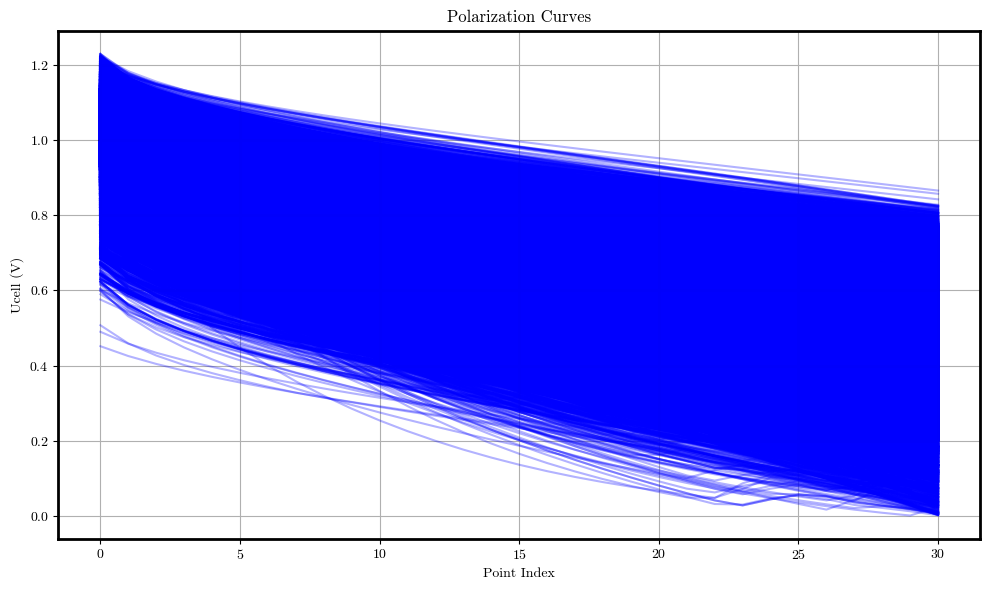

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Select only columns that start with "Ucell_"
ucell_columns = [col for col in df.columns if col.startswith("Ucell_")]

# Filter rows where all those columns are > 0
filtered_df = df[df[ucell_columns].gt(0).all(axis=1)]
# Loop through each row and plot the Ucell curve
for curve in filtered_df['Ucell']:
    plt.plot(curve, alpha=0.3, color='blue')  # alpha for transparency

plt.xlabel("Point Index")
plt.ylabel("Ucell (V)")
plt.title("Polarization Curves")
plt.grid(True)
plt.tight_layout()
plt.show()


In [113]:
data1['Ucell']

0        [0.994461179250021, 0.9441137804502849, 0.9153...
1        [0.9709775255652122, 0.9170699916248938, 0.884...
2        [0.9476850212017883, 0.9116546806288147, 0.885...
3        [1.1494636116993193, 1.0930650885159134, 1.059...
4        [1.0261453220238554, 0.957127735468104, 0.9167...
                               ...                        
41189    [0.9297067076227847, 0.8887136860399547, 0.861...
41190    [1.1125104459709898, 1.0712383248305146, 1.043...
41191    [0.9584735009031085, 0.9028894503100626, 0.871...
41192    [0.9088731831619759, 0.8678740709697281, 0.840...
41193    [0.9293615193453596, 0.8880849443187689, 0.860...
Name: Ucell, Length: 33072, dtype: object

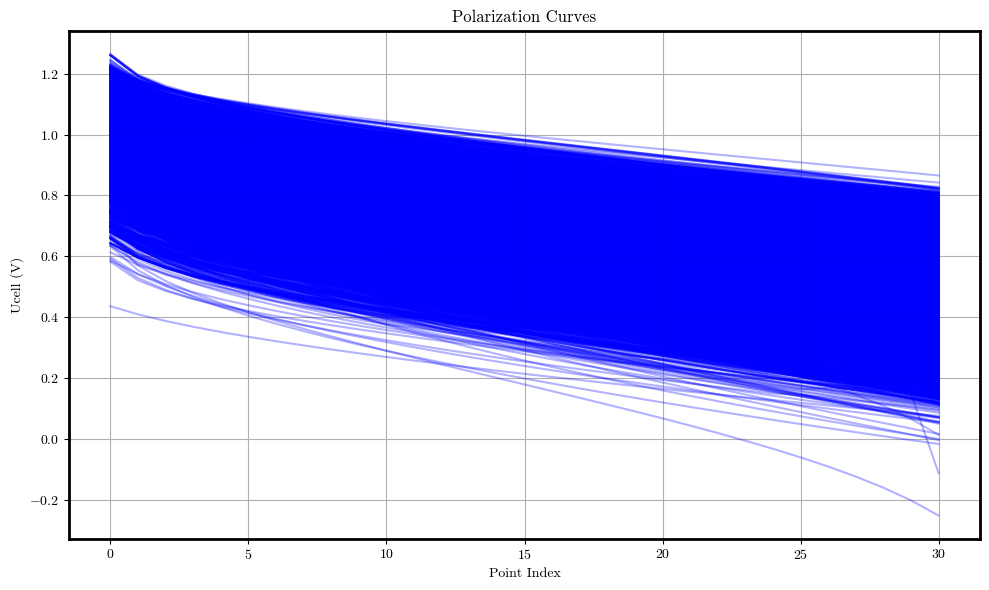

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for curve in data1['Ucell']:
    if curve is not None:
        plt.plot(curve, alpha=0.3, color='blue')

plt.xlabel("Point Index")
plt.ylabel("Ucell (V)")
plt.title("Polarization Curves")
plt.grid(True)
plt.tight_layout()
plt.show()
